# NBA Team Success Analysis

## Business Question

Which team statistics are most strongly associated with winning percentage in the NBA?

## Dataset

Source: NBA Stats API

Seasons:
- 2021-22
- 2022-23
- 2023-24
- 2024-25

Observations:
- 120 team-season records

## Data Loading 

In [2]:
import pandas as pd

df = pd.read_csv("../data/nba_team_stats.csv")

df.head()


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SEASON
0,1610612737,Atlanta Hawks,82,43,39,0.524,3941.0,3401,7241,0.470,...,15,1,22,23,10,7,6,6,14,2021-22
1,1610612738,Boston Celtics,82,51,31,0.622,3981.0,3341,7167,0.466,...,14,13,19,2,11,5,20,12,2,2021-22
2,1610612751,Brooklyn Nets,82,44,38,0.537,3951.0,3442,7251,0.475,...,10,17,24,5,21,22,16,9,15,2021-22
3,1610612766,Charlotte Hornets,82,43,39,0.524,3976.0,3508,7497,0.468,...,1,10,5,11,12,18,18,4,16,2021-22
4,1610612741,Chicago Bulls,82,46,36,0.561,3946.0,3422,7127,0.480,...,19,6,23,25,24,8,28,13,20,2021-22


In [3]:
df.shape

(120, 55)

In [4]:
df.columns

Index(['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS',
       'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK',
       'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK',
       'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK',
       'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK',
       'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK',
       'SEASON'],
      dtype='object')

## Exploratory Data Analysis

In [5]:
analysis_cols = [
    'TEAM_NAME',
    'SEASON',
    'W',
    'L',
    'W_PCT',
    'PTS',
    'REB',
    'AST',
    'TOV',
    'FG_PCT',
    'FG3_PCT',
    'PLUS_MINUS'
]

analysis_df = df[analysis_cols]

analysis_df.head()

,TEAM_NAME,SEASON,W,L,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,PLUS_MINUS
0,Atlanta Hawks,2021-22,43,39,0.524,9343,3606,2017,972.0,0.470,0.374,128.0
1,Boston Celtics,2021-22,51,31,0.622,9164,3778,2036,1118.0,0.466,0.356,597.0
2,Brooklyn Nets,2021-22,44,38,0.537,9258,3640,2071,1153.0,0.475,0.361,64.0
3,Charlotte Hornets,2021-22,43,39,0.524,9457,3655,2302,1087.0,0.468,0.365,36.0
4,Chicago Bulls,2021-22,46,36,0.561,9152,3471,1958,1053.0,0.480,0.369,-32.0


In [6]:
analysis_df.isnull().sum()

TEAM_NAME     0
SEASON        0
W             0
L             0
W_PCT         0
PTS           0
REB           0
AST           0
TOV           0
FG_PCT        0
FG3_PCT       0
PLUS_MINUS    0
dtype: int64

## Traditional Statistics Correlation Analysis 

In [7]:
corr = analysis_df.select_dtypes(include='number').corr()

corr['W_PCT'].sort_values(ascending=False)

W_PCT         1.000000
W             0.999998
PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
L            -0.999998
Name: W_PCT, dtype: float64

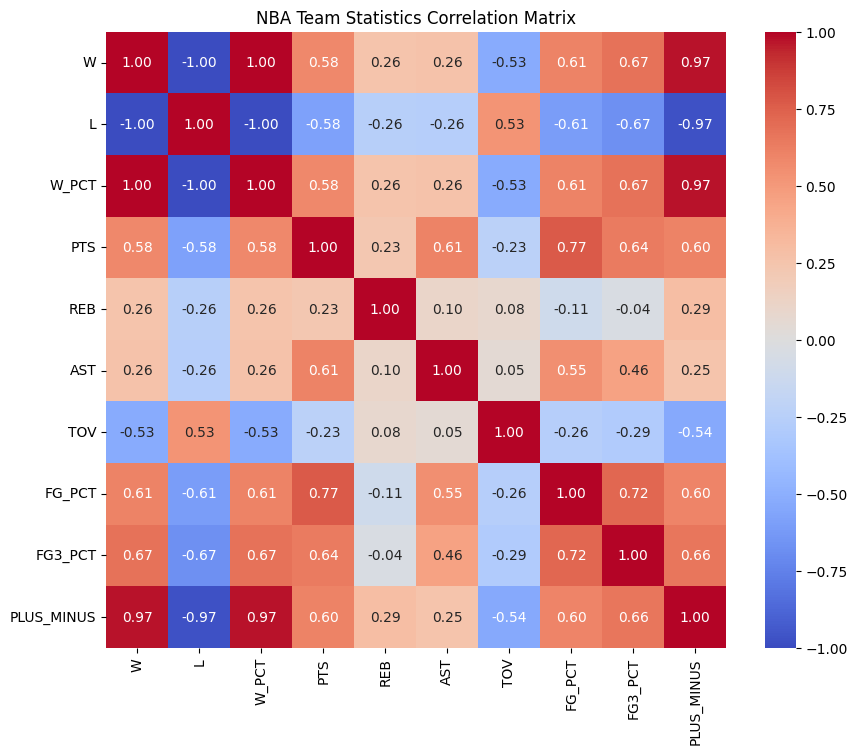

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr, 
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NBA Team Statistics Correlation Matrix')

plt.show()

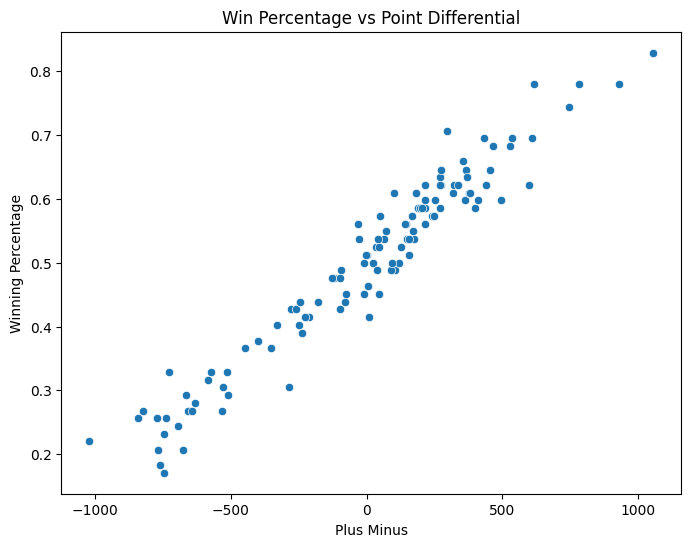

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=analysis_df,
    x='PLUS_MINUS',
    y='W_PCT'
)

plt.title('Win Percentage vs Point Differential')
plt.xlabel('Plus Minus')
plt.ylabel('Winning Percentage')

plt.show()

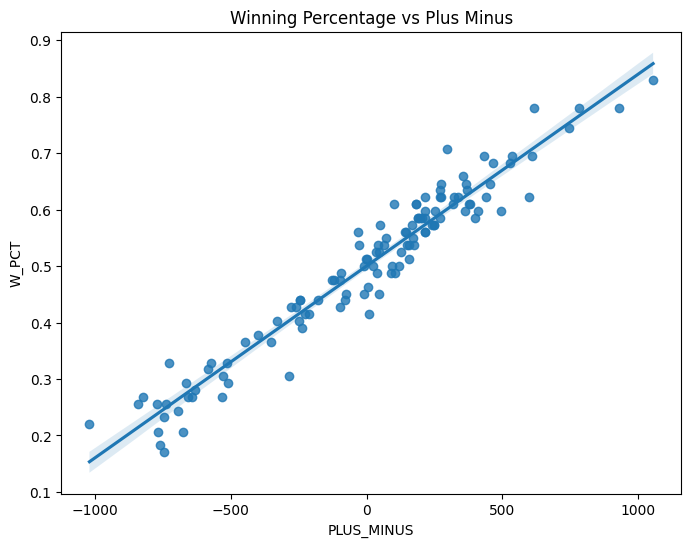

In [10]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=analysis_df,
    x='PLUS_MINUS',
    y='W_PCT'
)

plt.title('Winning Percentage vs Plus Minus')

plt.show()

Key Findings: 
1. Point differential (PLUS_MINUS) showed the strongest relationship with winning percentage.
2. Teams with higher field goal percentages generally won more games.
3. Assists were positively associated with team success. 
4. Turnovers showed a negative relationship with winning. 

In [11]:
corr['W_PCT'].sort_values(
    ascending=False
)

W_PCT         1.000000
W             0.999998
PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
L            -0.999998
Name: W_PCT, dtype: float64

In [12]:
[col for col in df.columns if 'RATING' in col]

[]

In [13]:
for col in df.columns:
    print(col)

TEAM_ID
TEAM_NAME
GP
W
L
W_PCT
MIN
FGM
FGA
FG_PCT
FG3M
FG3A
FG3_PCT
FTM
FTA
FT_PCT
OREB
DREB
REB
AST
TOV
STL
BLK
BLKA
PF
PFD
PTS
PLUS_MINUS
GP_RANK
W_RANK
L_RANK
W_PCT_RANK
MIN_RANK
FGM_RANK
FGA_RANK
FG_PCT_RANK
FG3M_RANK
FG3A_RANK
FG3_PCT_RANK
FTM_RANK
FTA_RANK
FT_PCT_RANK
OREB_RANK
DREB_RANK
REB_RANK
AST_RANK
TOV_RANK
STL_RANK
BLK_RANK
BLKA_RANK
PF_RANK
PFD_RANK
PTS_RANK
PLUS_MINUS_RANK
SEASON


In [14]:
corr_wpct = (
    corr["W_PCT"]
    .drop(["W_PCT", "W", "L"])
    .sort_values(ascending=False)
)

corr_wpct

PLUS_MINUS    0.968971
FG3_PCT       0.674250
FG_PCT        0.608092
PTS           0.583755
AST           0.258251
REB           0.257520
TOV          -0.528283
Name: W_PCT, dtype: float64

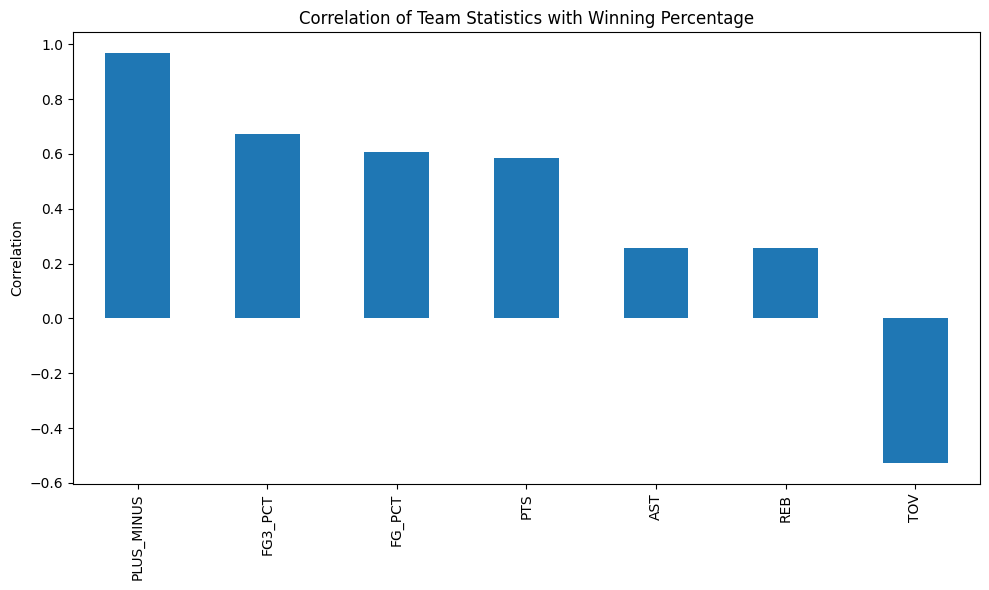

In [15]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,6))

corr_wpct.plot(
    kind="bar"
)

plt.title(
    "Correlation of Team Statistics with Winning Percentage"
)

plt.ylabel("Correlation")

plt.tight_layout()

plt.show()

## Executive Summary

This analysis examined NBA team performance across four seasons
(2021-22 through 2024-25) to determine which statistics are most
strongly associated with winning percentage.

Key Findings:

- Point differential (PLUS_MINUS) had the strongest positive
  relationship with winning percentage.

- Three-point shooting percentage showed a stronger relationship
  with winning than overall field goal percentage.

- Teams that committed more turnovers tended to have lower
  winning percentages.

- Rebounding and assists were positively related to winning,
  but less strongly than shooting efficiency metrics.

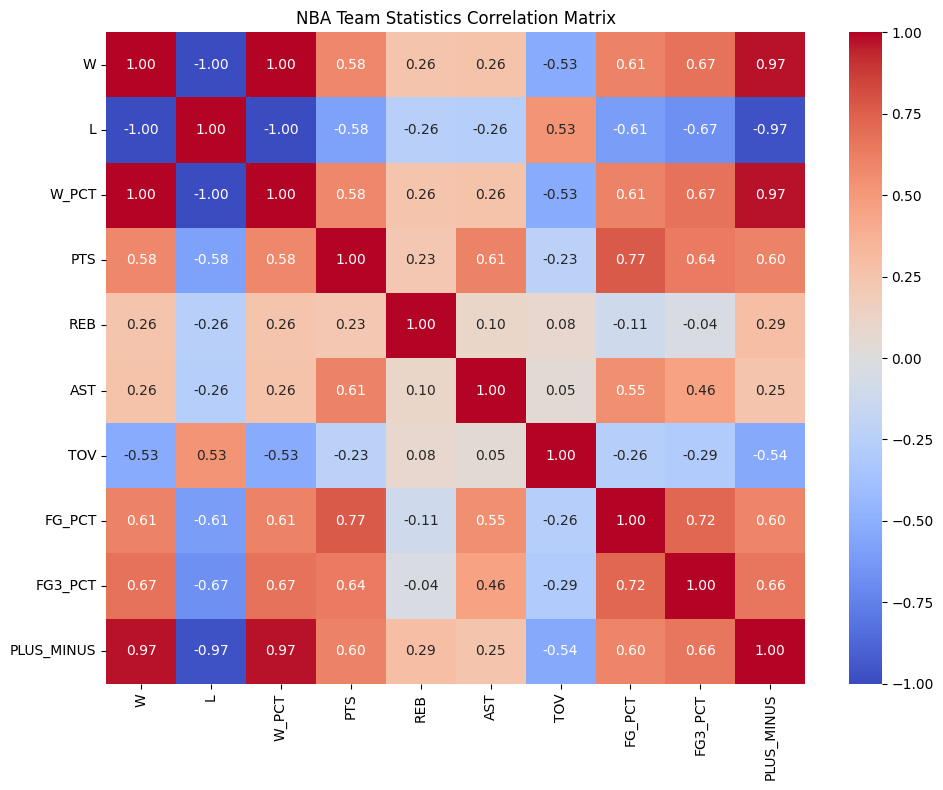

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NBA Team Statistics Correlation Matrix"
)

plt.tight_layout()

plt.show()

Questions???

-- Which metrics move together?
-- Is FG3_PCT strongly related to PTS?
-- Is TOV negatively related to winning? 
-- Are REB and AST strongly connected?

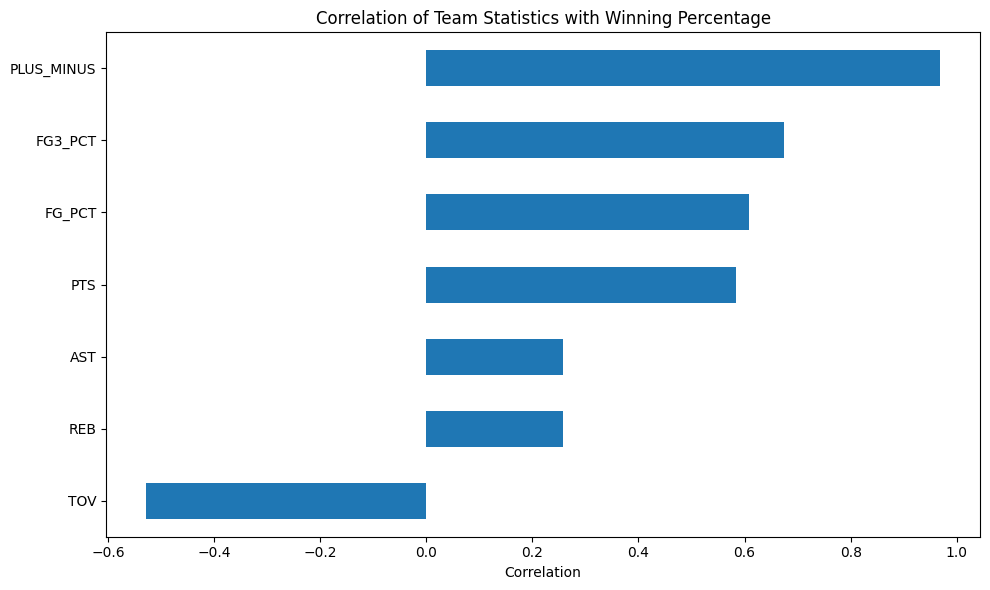

In [17]:
corr_wpct = (
    corr["W_PCT"]
    .drop(["W_PCT", "W", "L"])
    .sort_values()
)

plt.figure(figsize=(10,6))

corr_wpct.plot(
    kind="barh"
)

plt.title(
    "Correlation of Team Statistics with Winning Percentage"
)

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

# Key Finding #1

Point differential (PLUS_MINUS) demonstrated the strongest
relationship with winning percentage (r = 0.97).

This suggests that teams consistently outscoring opponents
are significantly more likely to achieve successful seasons.

Three-point shooting percentage showed a stronger relationship
with winning than overall field-goal percentage, highlighting
the importance of perimeter shooting in the modern NBA.

In [18]:
analysis_df.sort_values(
    by="W_PCT",
    ascending=False
)[
    ["TEAM_NAME", "SEASON", "W_PCT"]
].head(15)

,TEAM_NAME,SEASON,W_PCT
110,Oklahoma City Thunder,2024-25,0.829
23,Phoenix Suns,2021-22,0.780
61,Boston Celtics,2023-24,0.780
95,Cleveland Cavaliers,2024-25,0.780
91,Boston Celtics,2024-25,0.744
46,Milwaukee Bucks,2022-23,0.707
31,Boston Celtics,2022-23,0.695
80,Oklahoma City Thunder,2023-24,0.695
67,Denver Nuggets,2023-24,0.695
77,Minnesota Timberwolves,2023-24,0.683


In [19]:
top_teams = (
    analysis_df
    .sort_values("W_PCT", ascending=False)
    .head(10)
)

bottom_teams = (
    analysis_df
    .sort_values("W_PCT")
    .head(10)
)

top_teams.describe()

,W,L,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,PLUS_MINUS
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,60.600000,21.400000,0.738800,9650.600000,3699.600000,2222.400000,1058.600000,0.483500,0.377200,653.000000
std,4.168666,4.168666,0.050701,246.154965,140.310925,85.215022,79.135889,0.011138,0.009126,228.980349
min,56.000000,14.000000,0.683000,9264.000000,3447.000000,2115.000000,961.000000,0.462000,0.364000,298.000000
25%,57.000000,18.000000,0.695000,9447.000000,3650.250000,2184.500000,993.250000,0.476750,0.369500,530.500000
50%,59.500000,22.500000,0.725500,9630.000000,3715.000000,2204.500000,1049.500000,0.485000,0.375500,611.500000
75%,64.000000,25.000000,0.780000,9872.500000,3721.500000,2238.750000,1091.750000,0.490000,0.386000,773.250000
max,68.000000,26.000000,0.829000,9999.000000,3988.000000,2415.000000,1199.000000,0.499000,0.389000,1055.000000


In [20]:
bottom_teams.describe()

,W,L,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,PLUS_MINUS
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,18.300000,63.700000,0.223200,8949.600000,3524.400000,2038.500000,1252.100000,0.451700,0.346700,-776.400000
std,2.540779,2.540779,0.030936,217.528134,134.042448,121.854421,85.207524,0.012266,0.005832,96.539226
min,14.000000,61.000000,0.171000,8618.000000,3303.000000,1884.000000,1129.000000,0.430000,0.335000,-1020.000000
25%,17.000000,61.250000,0.207000,8769.000000,3454.500000,1947.500000,1210.000000,0.442250,0.345500,-771.250000
50%,18.500000,63.500000,0.226000,9001.500000,3529.000000,2045.500000,1248.500000,0.454000,0.348000,-754.500000
75%,20.750000,65.000000,0.253000,9036.250000,3581.250000,2091.750000,1274.750000,0.459000,0.349750,-741.750000
max,21.000000,68.000000,0.256000,9327.000000,3724.000000,2290.000000,1412.000000,0.470000,0.355000,-674.000000


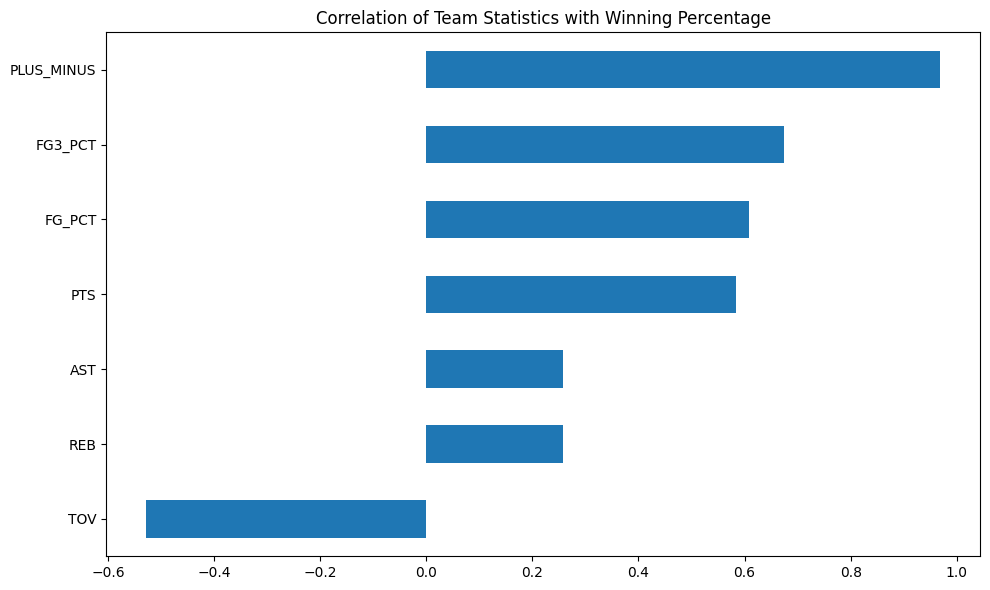

In [21]:
plt.figure(figsize=(10,6))

corr_wpct.plot(kind="barh")

plt.title(
    "Correlation of Team Statistics with Winning Percentage"
)

plt.tight_layout()

plt.savefig(
    "../outputs/top_drivers_of_winning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

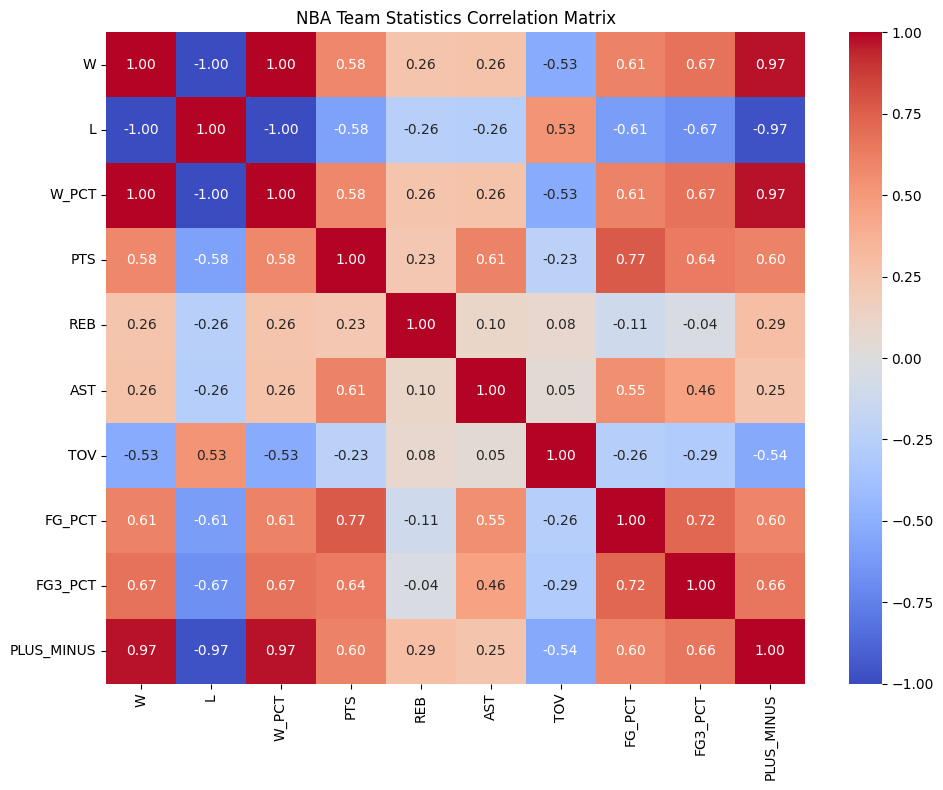

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NBA Team Statistics Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../outputs/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
advanced_df = pd.read_csv(
    "../data/nba_team_advanced_stats.csv"
)

advanced_df.columns.tolist()

['TEAM_ID',
 'TEAM_NAME',
 'GP',
 'W',
 'L',
 'W_PCT',
 'MIN',
 'E_OFF_RATING',
 'OFF_RATING',
 'E_DEF_RATING',
 'DEF_RATING',
 'E_NET_RATING',
 'NET_RATING',
 'AST_PCT',
 'AST_TO',
 'AST_RATIO',
 'OREB_PCT',
 'DREB_PCT',
 'REB_PCT',
 'TM_TOV_PCT',
 'EFG_PCT',
 'TS_PCT',
 'E_PACE',
 'PACE',
 'PACE_PER40',
 'POSS',
 'PIE',
 'GP_RANK',
 'W_RANK',
 'L_RANK',
 'W_PCT_RANK',
 'MIN_RANK',
 'OFF_RATING_RANK',
 'DEF_RATING_RANK',
 'NET_RATING_RANK',
 'AST_PCT_RANK',
 'AST_TO_RANK',
 'AST_RATIO_RANK',
 'OREB_PCT_RANK',
 'DREB_PCT_RANK',
 'REB_PCT_RANK',
 'TM_TOV_PCT_RANK',
 'EFG_PCT_RANK',
 'TS_PCT_RANK',
 'PACE_RANK',
 'PIE_RANK',
 'SEASON']

## Advamced Metrics Analysis 

In [24]:
advanced_cols = [
    "W_PCT",
    "OFF_RATING",
    "DEF_RATING",
    "NET_RATING",
    "EFG_PCT",
    "TS_PCT",
    "PACE",
    "AST_PCT",
    "REB_PCT"
]

advanced_analysis = advanced_df[
    advanced_cols
]

advanced_corr = advanced_analysis.corr()

advanced_corr["W_PCT"].sort_values(
    ascending=False
)

W_PCT         1.000000
NET_RATING    0.967154
OFF_RATING    0.791618
TS_PCT        0.677776
EFG_PCT       0.677556
REB_PCT       0.429474
AST_PCT      -0.003950
PACE         -0.187510
DEF_RATING   -0.710779
Name: W_PCT, dtype: float64

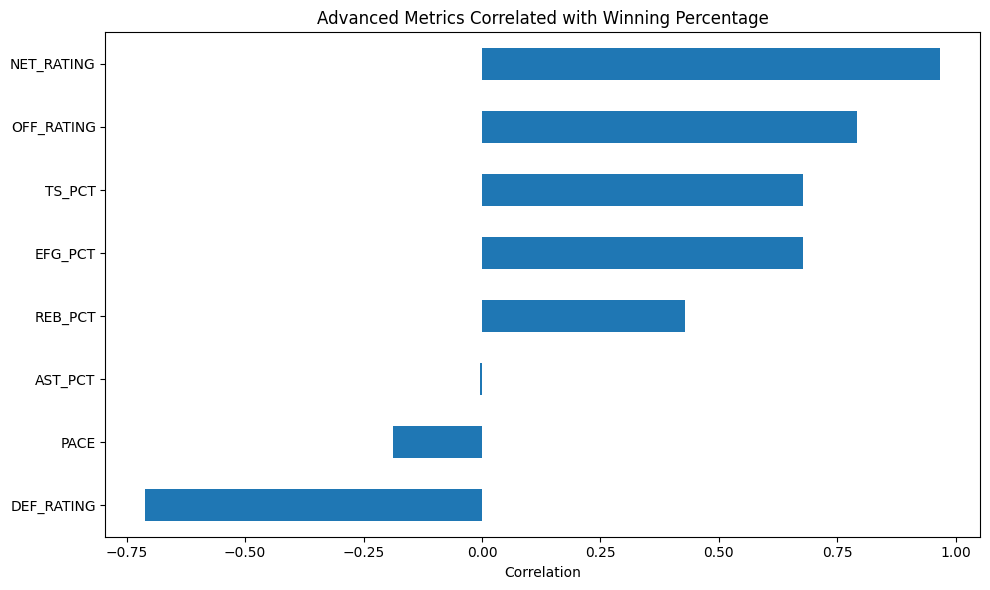

In [50]:
advanced_wpct = (
    advanced_corr["W_PCT"]
    .drop("W_PCT")
    .sort_values()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

advanced_wpct.plot(
    kind="barh"
)

plt.title(
    "Advanced Metrics Correlated with Winning Percentage"
)

plt.xlabel("Correlation")

plt.tight_layout()

plt.savefig(
    "../outputs/advanced_metrics_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Overperformers and Underperformers

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
from sklearn.linear_model import LinearRegression

X = advanced_df[["NET_RATING"]]

y = advanced_df["W_PCT"]

model = LinearRegression()

model.fit(X, y)

advanced_df["EXPECTED_W_PCT"] = model.predict(X)

advanced_df.head()

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,...,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK,SEASON,EXPECTED_W_PCT
0,1610612737,Atlanta Hawks,82,43,39,0.524,3941.0,114.0,115.4,112.1,...,17,12,14,1,8,6,17,14,2021-22,0.544071
1,1610612738,Boston Celtics,82,51,31,0.622,3981.0,112.1,113.6,104.0,...,11,16,10,13,9,9,24,2,2021-22,0.705626
2,1610612751,Brooklyn Nets,82,44,38,0.537,3951.0,111.0,113.2,109.6,...,9,30,15,18,11,11,11,11,2021-22,0.524573
3,1610612766,Charlotte Hornets,82,43,39,0.524,3976.0,111.7,113.6,111.0,...,14,29,27,9,7,13,5,15,2021-22,0.513431
4,1610612741,Chicago Bulls,82,46,36,0.561,3946.0,111.0,112.7,111.1,...,28,7,17,6,10,8,14,20,2021-22,0.485577


In [36]:
advanced_df["OVERPERFORMANCE"] = (
    advanced_df["W_PCT"]
    - advanced_df["EXPECTED_W_PCT"]
)

In [37]:
advanced_df[
    [
        "TEAM_NAME",
        "SEASON",
        "W_PCT",
        "EXPECTED_W_PCT",
        "OVERPERFORMANCE"
    ]
].sort_values(
    by="OVERPERFORMANCE",
    ascending=False
).head(15)

,TEAM_NAME,SEASON,W_PCT,EXPECTED_W_PCT,OVERPERFORMANCE
46,Milwaukee Bucks,2022-23,0.707,0.594209,0.112791
24,Portland Trail Blazers,2021-22,0.329,0.246031,0.082969
103,Los Angeles Lakers,2024-25,0.610,0.532929,0.077071
4,Chicago Bulls,2021-22,0.561,0.485577,0.075423
23,Phoenix Suns,2021-22,0.780,0.708411,0.071589
119,Washington Wizards,2024-25,0.220,0.159682,0.060318
73,Los Angeles Lakers,2023-24,0.573,0.516217,0.056783
37,Denver Nuggets,2022-23,0.646,0.591423,0.054577
66,Dallas Mavericks,2023-24,0.610,0.557998,0.052002
101,Indiana Pacers,2024-25,0.610,0.557998,0.052002


In [38]:
advanced_df[
    [
        "TEAM_NAME",
        "SEASON",
        "W_PCT",
        "EXPECTED_W_PCT",
        "OVERPERFORMANCE"
    ]
].sort_values(
    by="OVERPERFORMANCE"
).head(15)

,TEAM_NAME,SEASON,W_PCT,EXPECTED_W_PCT,OVERPERFORMANCE
11,Indiana Pacers,2021-22,0.305,0.399229,-0.094229
26,San Antonio Spurs,2021-22,0.415,0.505075,-0.090075
1,Boston Celtics,2021-22,0.622,0.705626,-0.083626
68,Detroit Pistons,2023-24,0.171,0.248816,-0.077816
28,Utah Jazz,2021-22,0.598,0.672201,-0.074201
89,Washington Wizards,2023-24,0.183,0.257172,-0.074172
38,Detroit Pistons,2022-23,0.207,0.279456,-0.072456
105,Miami Heat,2024-25,0.451,0.510646,-0.059646
86,San Antonio Spurs,2023-24,0.268,0.321237,-0.053237
34,Chicago Bulls,2022-23,0.488,0.535715,-0.047715


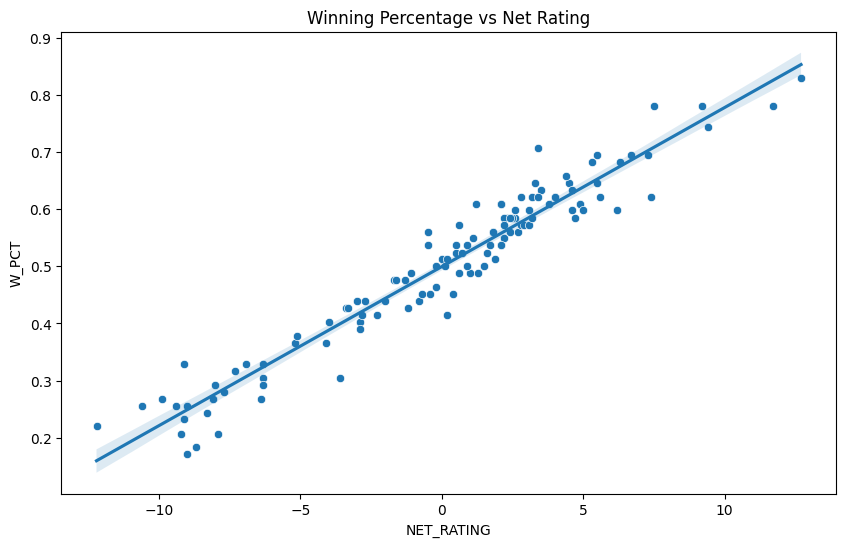

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=advanced_df,
    x="NET_RATING",
    y="W_PCT"
)

sns.regplot(
    data=advanced_df,
    x="NET_RATING",
    y="W_PCT",
    scatter=False
)

plt.title(
    "Winning Percentage vs Net Rating"
)

plt.show()

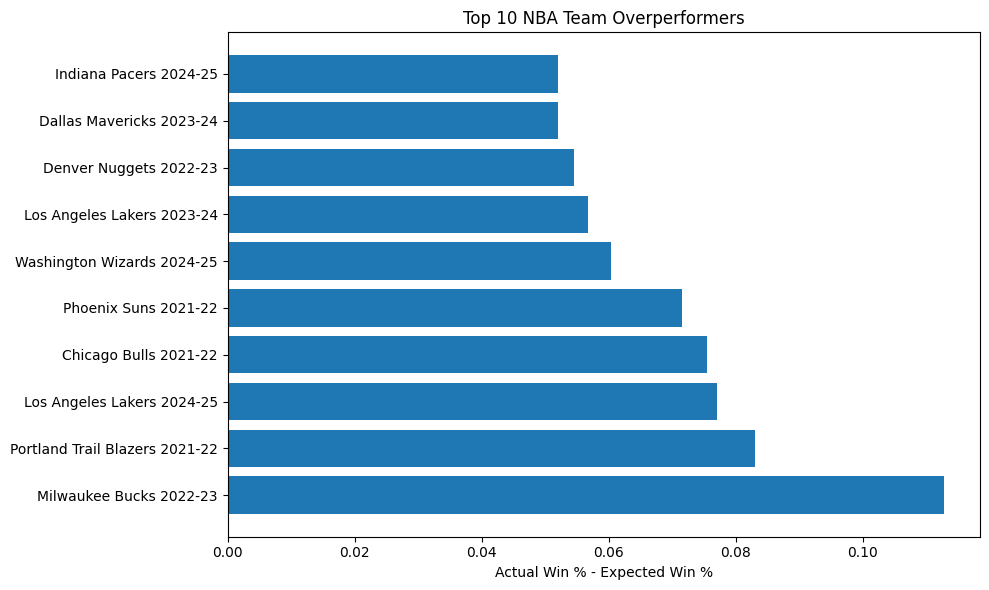

In [49]:
top10 = (
    advanced_df[
        [
            "TEAM_NAME",
            "SEASON",
            "OVERPERFORMANCE"
        ]
    ]
    .sort_values(
        "OVERPERFORMANCE",
        ascending=False
    )
    .head(10)
)

top10["LABEL"] = (
    top10["TEAM_NAME"]
    + " "
    + top10["SEASON"]
)

plt.figure(figsize=(10,6))

plt.barh(
    top10["LABEL"],
    top10["OVERPERFORMANCE"]
)

plt.title(
    "Top 10 NBA Team Overperformers"
)

plt.xlabel(
    "Actual Win % - Expected Win %"
)

plt.tight_layout()

plt.savefig(
    "../outputs/overperformers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

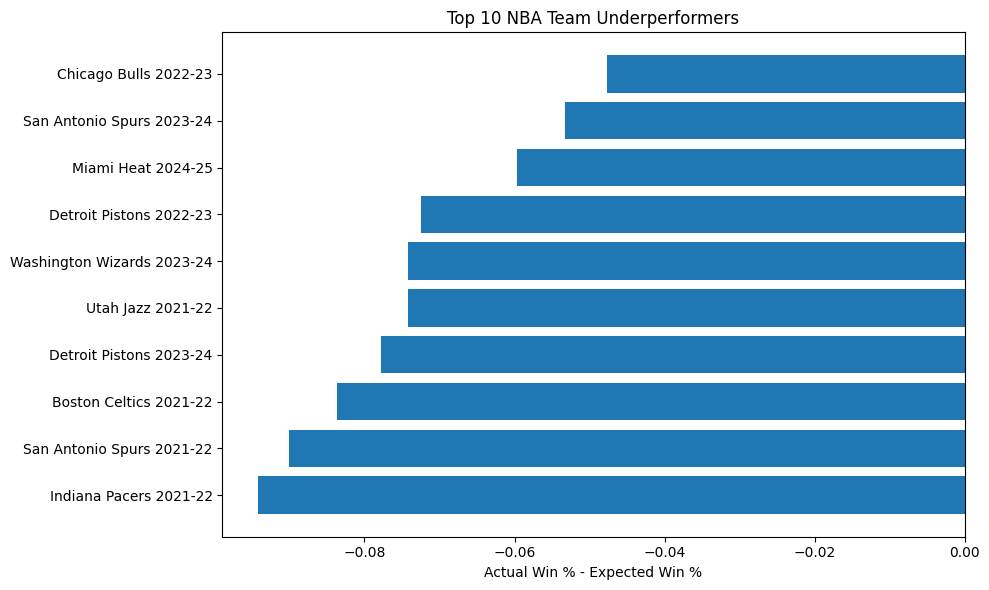

In [48]:
bottom10 = (
    advanced_df[
        [
            "TEAM_NAME",
            "SEASON",
            "OVERPERFORMANCE"
        ]
    ]
    .sort_values(
        "OVERPERFORMANCE",
        ascending=True
    )
    .head(10)
)

bottom10["LABEL"] = (
    bottom10["TEAM_NAME"]
    + " "
    + bottom10["SEASON"]
)

plt.figure(figsize=(10,6))

plt.barh(
    bottom10["LABEL"],
    bottom10["OVERPERFORMANCE"]
)

plt.title(
    "Top 10 NBA Team Underperformers"
)

plt.xlabel(
    "Actual Win % - Expected Win %"
)

plt.tight_layout()

plt.savefig(
    "../outputs/underperformers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>